# Phase 1: Data Exploration

This notebook verifies the integrity of the downloaded Kaggle dataset.
It counts the images, analyzes the class distribution, and performs visual audits of the raw data.

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

RAW_DIR = '../data/raw'
CLASSES = ['normal', 'diabetic_retinopathy', 'cataract', 'glaucoma']

## 1. Verify Integrity: Image Counts

In [2]:
stats = []
for cls in CLASSES:
    cls_dir = os.path.join(RAW_DIR, cls)
    if not os.path.exists(cls_dir):
        print(f"Warning: Directory not found -> {cls_dir}")
        continue
        
    files = os.listdir(cls_dir)
    
    valid_exts = ['.jpg', '.jpeg', '.png']
    valid_files = [f for f in files if any(f.lower().endswith(ext) for ext in valid_exts)]
    invalid_files = [f for f in files if not any(f.lower().endswith(ext) for ext in valid_exts)]
    
    stats.append({
        'Class Name': cls,
        'Valid Images': len(valid_files),
        'Invalid Files': len(invalid_files)
    })
    
    if len(invalid_files) > 0:
        print(f"Found invalid files in {cls}: {invalid_files[:5]}...")

df_stats = pd.DataFrame(stats)
print("\nDataset Integrity Report:")
display(df_stats)


Dataset Integrity Report:


,Class Name,Valid Images,Invalid Files
0,normal,1074,0
1,diabetic_retinopathy,1098,0
2,cataract,1038,0
3,glaucoma,1007,0


## 2. Class Distribution Bar Chart

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7432\304814112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class Name', y='Valid Images', data=df_stats, palette='viridis')


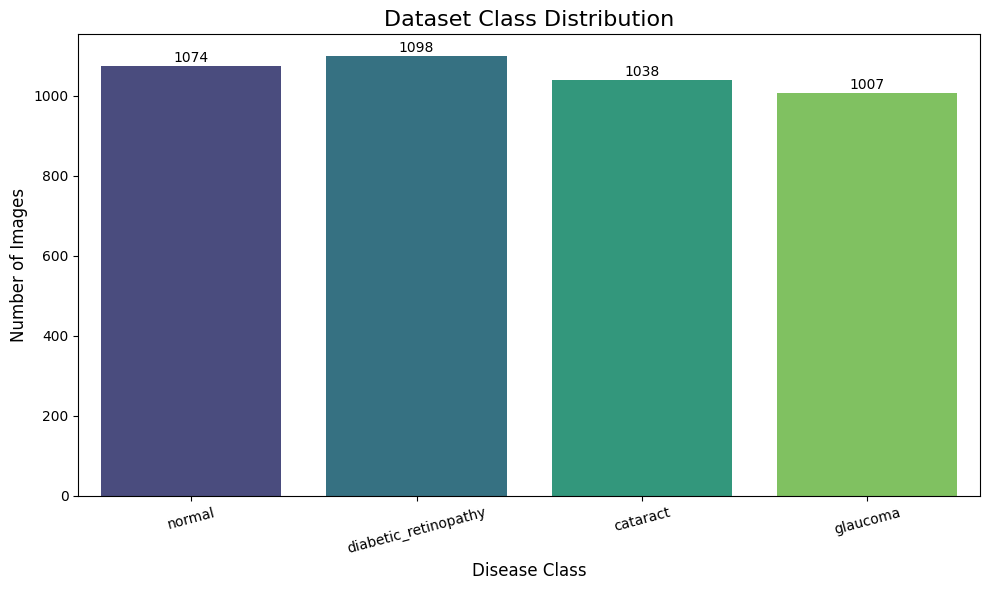

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Class Name', y='Valid Images', data=df_stats, palette='viridis')
plt.title('Dataset Class Distribution', fontsize=16)
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Disease Class', fontsize=12)
plt.xticks(rotation=15)
for index, row in enumerate(df_stats['Valid Images']):
    plt.text(index, row + 10, str(row), color='black', ha="center")
plt.tight_layout()
plt.show()

## 3. Visual Audit: Raw Data
Let's look at 5 random images from each class to check for large black borders or extremely dark images.

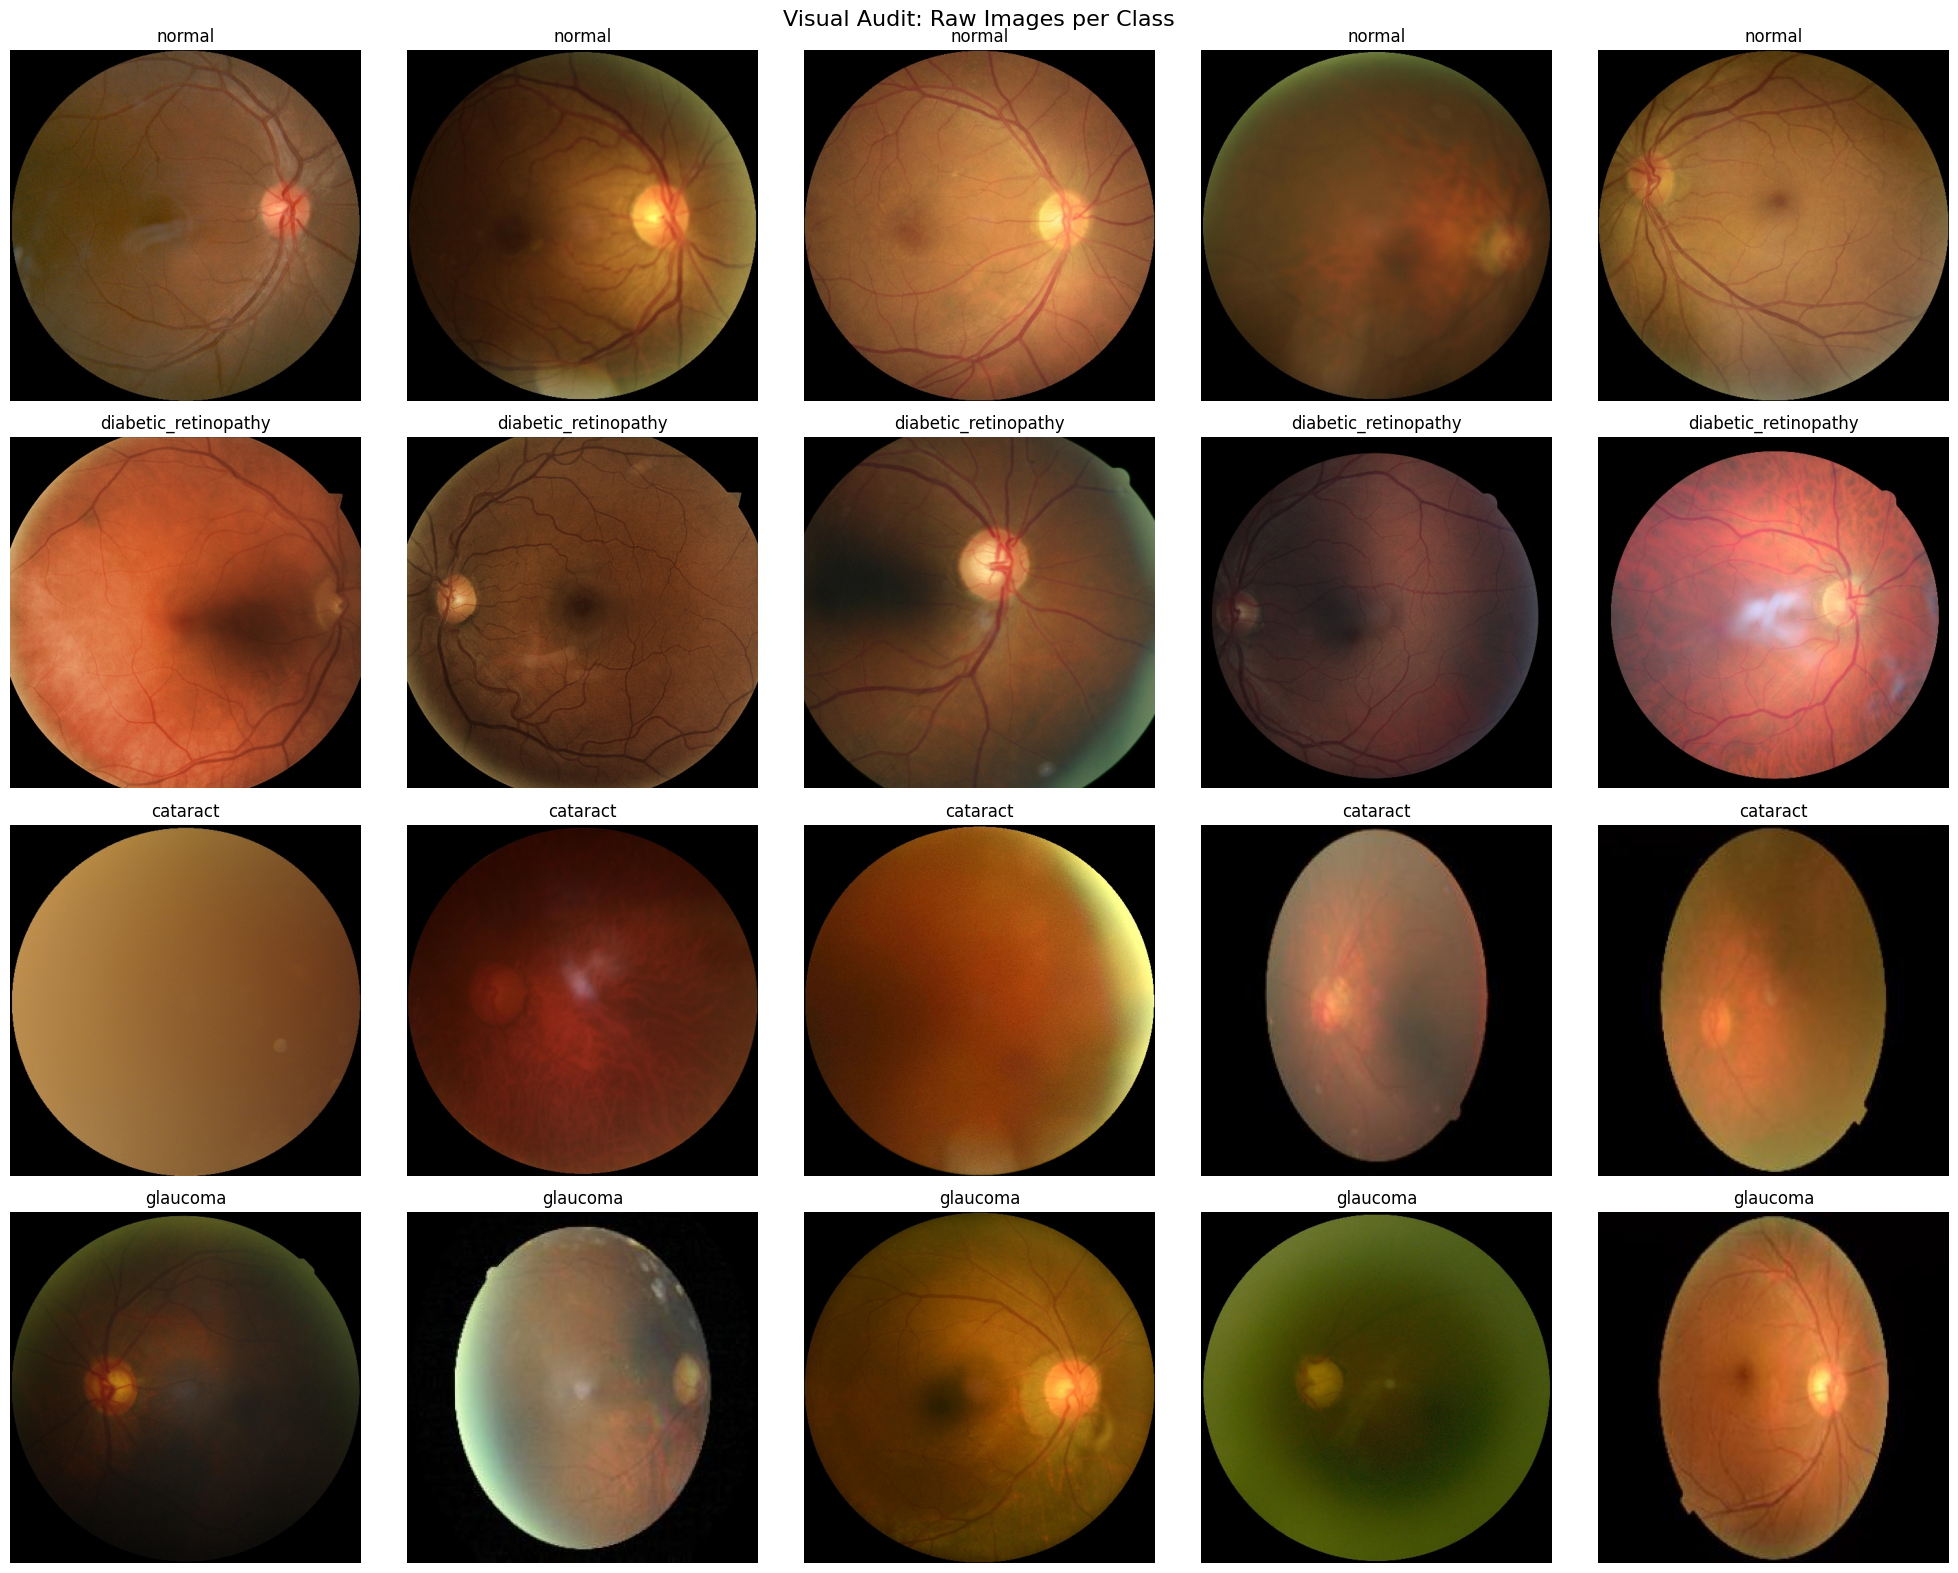

In [4]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(20, 4 * len(CLASSES)))
fig.suptitle('Visual Audit: Raw Images per Class', fontsize=16)

for idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(RAW_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
        
    images = glob.glob(os.path.join(cls_dir, '*.*'))
    sample_images = random.sample(images, min(5, len(images)))
    
    for j, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx, j].imshow(img_rgb)
            axes[idx, j].set_title(cls)
            axes[idx, j].axis('off')

plt.tight_layout()
plt.show()